# Tarea 3: Clasificación de galaxias con una CNN

**Estudiantes:** *Cristóbal Castro Riquelme y Vanessa Meza Aravena.*

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

I0000 00:00:1786149997.446924    6545 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786150001.387162    6545 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786150005.658777    6545 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [2]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive')

Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [ ]:
path = "/content/drive/MyDrive/BigData/Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive

## 1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?

      Visualmente notamos que las galaxias *smooth* tienden a ser circulares, con un punto brillante al medio y un halo a su alrededor que se difumina tenuemente. En cambio, las galaxias *barred spiral* son galaxias barradas, con brazos espirales visibles y mas elípticas.

   - ¿Qué características espera que pueda aprender la red?

      La red debería ser capaz de diferenciar ambos tipos de galaxias según la morfología de estas (si tiene o no brazos espirales visibles) o utilizando la inclinación/forma de estas.

   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?

      La clase *Round Smooth* es la que presenta una mayor proporción, de 2645/4688, aproximadamente un 56.42% versus *Barred Spiral*, de un 43.58%
      Nuestro accuracy base para predecir la clase más frecuente sería de 56.4%, que nos servirá como referencia para comparar con el modelo real.
   

In [4]:
with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


In [5]:
#Para la proporción de clases
round_smooth_prop = (2645 / 4688) * 100
barred_spiral_prop = (2043 / 4688) * 100
print (f"{round_smooth_prop:.2f}%")
print (f"{barred_spiral_prop:.2f}%")

56.42%
43.58%


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [6]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

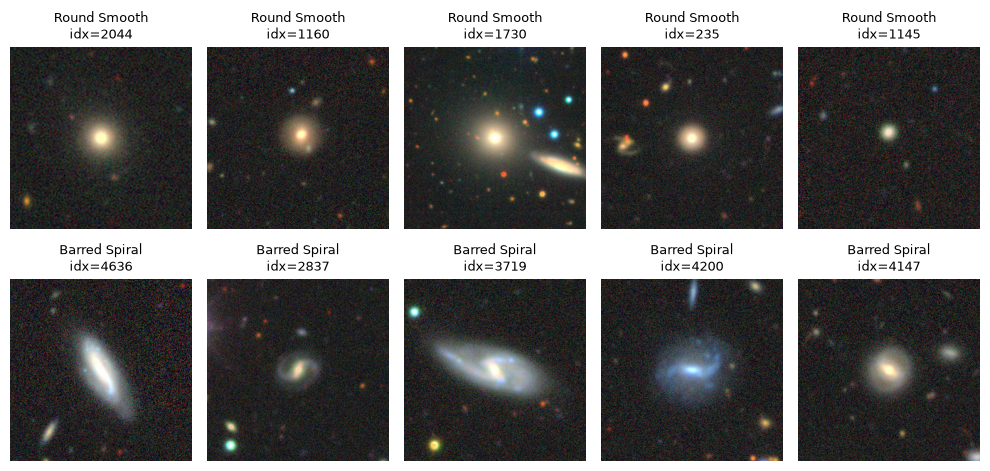

In [7]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

## 2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos

      Para estas tres separaciones necesitamos entender como funciona parcialmente las redes. El train es con lo que esta red ajusta los pesos, mientras que la validación se utiliza para "guiar" las decisiones durante todo el desarrollo de la red neuronal. Finalmente, el test solo se toca al final para ver la estimación de como generalizaría este modelo de forma más "honesta". Necesitamos estas tres separaciones para evitar el overfitting o sobreestimar que tan bien hecho está el modelo.

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [8]:
#Para el primer split haremos una separación 20/80
#Separamos x e y en dos partes principales, donde el 80% se va a X_temp y y_temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#Aquí realizamos un segunda separación utilizando esta vez X_temp y y_temp que nos permitirá
#monitorear el rendimiento y prevenir el overffiting
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.27,
    stratify=y_temp,
    random_state=42
)

#Para ver como quedaron los train y test después del split
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (2737, 256, 256, 3) (2737,)
Val: (1013, 256, 256, 3) (1013,)
Test: (938, 256, 256, 3) (938,)
Train classes: (array([0, 1], dtype=int32), array([1544, 1193]))
Val classes: (array([0, 1], dtype=int32), array([572, 441]))
Test classes: (array([0, 1], dtype=int32), array([529, 409]))


## 3. **Arquitectura de la red**
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

1. Idealmente, buscamos trabajar con con 2-3 capas convolucionales. Esto debido a que el problema se resume a una clasificación binaria.
2. 32-64 filtros, de forma que estos filtros van aumentando a medida que las capas convolucionales los necesiten. Las capas más profundas necesitan más complejidad.
3. relu, ya que es una opción estandar al trabajar con capas convolucionales y funciona bastante bien con problemas de clasificación binario sin involucrarse en un gradiente.
4. Como los datos son bastante grandes, nos interesa disminuir la complejidad de estos mediante una reducción espacial, de forma que utilizaremos MaxPooling después de cada capa. Disminuye el costo computacional.
5. Utilizamos GlobalAveragePooling2D, ya que Flatten convierte este mapa en un vector largo, mientras que GlobalAveragePooling2D promedia cada mapa, lo que nos da un vector mucho más pequeño y manejable.
6. Sí, utilizaremos Early Stopping con un patience de 3. En este caso, es necesaria ya que tenemos un dataset bastante rico en información y esta red puede empezar a memorizar si dejamos que trabaje con todos. Nos ayuda a controlar mejor la generalización y que realmente esté aprendiendo.
7. Sigmoid debe utilizar 1 neurona de salida. Necesitamos obtener la probabilidad entre 0 y 1 para este caso de clasificación binaria.
8. binary_crossentropy, ya que es la función estándar predeterminada para la clasificación binaria con la salida sigmoide.

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(____, kernel_size=____, activation=____)
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.________________()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [9]:

tf.random.set_seed(42) #Para mantener la reproductibilidad, fijamos una semilla determinada

#Para el modelo
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #Donde aquí identificamos el alto, el ancho y los canales RGB que son 3
    layers.Rescaling(1./255), #Normalizamos los píxeles (originalmente en un rango de [0, 255]) para tener una forma [0, 1]

    #El bloque convolucional 1
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(), #Después de cada bloque reducimos el tamaño del mapa de características para reducir el costo computacional

    #El bloque convolucional 2
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    #Usamos AveragePooling para reducir las características
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),

    #Hacemos la capa de salida utilizando sigmoide, ya que es la mejor función de activación para trabajar con clasificación binaria
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam", #Usamos el optimizador Adam
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1786150024.674863    6545 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13548 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)


4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable

In [10]:
#Para la regularización, utilizamos early stopping con una paciencia de 3 épocas ya que es parcialmente
#más manejable que Dropout para este caso.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#Aquí entrenamos finalmente el modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/15


I0000 00:00:1786150027.422826    6640 service.cc:153] XLA service 0x7b31bc034b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786150027.422846    6640 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786150027.466137    6640 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786150027.621262    6640 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786150027.627929    6640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1748__.28
I0000 00:00:1786150032.918536    6640 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set ins

10/86 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5656 - loss: 0.6909

I0000 00:00:1786150035.578855    6640 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5629 - loss: 0.6867

I0000 00:00:1786150037.151407    6640 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1748__.28
I0000 00:00:1786150037.342543    6640 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786150037.568433    6896 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 76 bytes spill stores, 76 bytes spill loads

I0000 00:00:1786150038.109198    6640 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5627 - loss: 0.6867

I0000 00:00:1786150040.793007    6639 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786150041.039316    7147 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 76 bytes spill stores, 76 bytes spill loads



86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.5627 - loss: 0.6867 - val_accuracy: 0.5647 - val_loss: 0.6828
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5652 - loss: 0.6799 - val_accuracy: 0.5706 - val_loss: 0.6702
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6303 - loss: 0.6408 - val_accuracy: 0.6417 - val_loss: 0.6150
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7165 - loss: 0.5683 - val_accuracy: 0.6989 - val_loss: 0.5556
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7541 - loss: 0.5158 - val_accuracy: 0.7206 - val_loss: 0.5234
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7753 - loss: 0.4918 - val_accuracy: 0.7364 - val_loss: 0.5091
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7797 - loss: 0.4787 - val_accuracy: 0.7463 - val_loss: 0.5072
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7808 - loss: 0.4693 - val_accuracy: 0.7463 - val_loss: 0

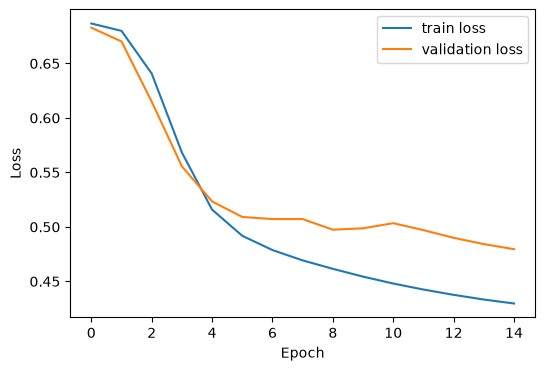

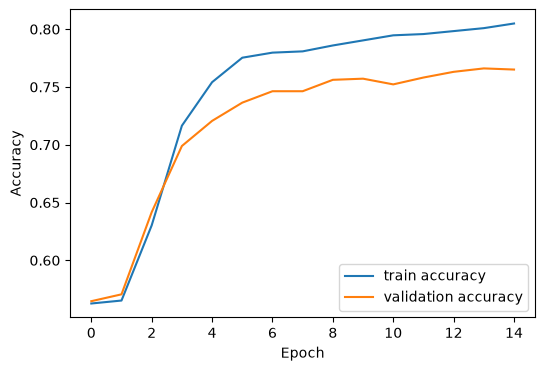

In [11]:
#Para poder visualizar los gráficos de validation loss y accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [12]:
#Para el testeo de loss y accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7729 - loss: 0.4720
Test loss: 0.4720
Test accuracy: 0.7729


### Análisis de gráficos
Si notamos las curvas y los valores del test, el accuracy de entrenamiento pasó de un valor base de 0.56 a un 0.80, mientras que el loss bajó de 0.69 a 0.43. En validación, el accuracy llega a 0.77 y el loss a 0.47.

En este caso, el val_loss desde la época 4 en adelante queda por encima del train_loss con una diferencia relativamente estable (es decir, que no crece abruptamente). De forma similar, el accuracy de validación también queda un poco por debajo del de entrenamiento

Esto se puede interpretar como un overfitting leve, donde el modelo empieza a ajustarse mejor a los datos de entrenamiento que de validación que vale la pena considerar.Pero el efecto no fue tan severo ya que el early Stopping no llego a activarse y se completaron las 15 epocas.

En general, el rendimiento se ve bastante bueno analizando las curvas de accuracy y loss, pero existe un riesgo de overfitting que es importante a tener en cuenta.

## 5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique

#### Genere la matriz de confusión y las métricas

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


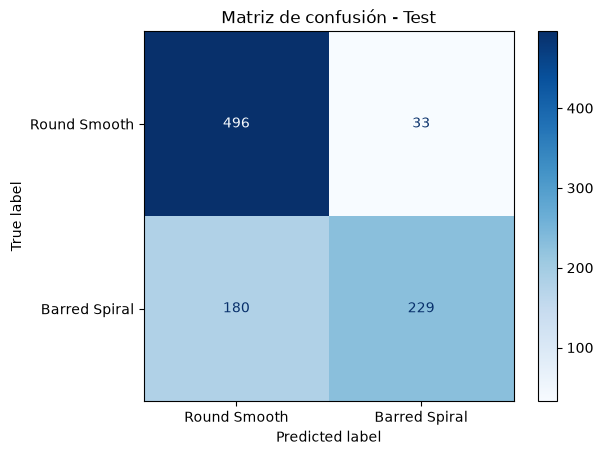

In [13]:
#Para la matriz de confusión, es necesario convertir estas clases a binarias
#(de la probabilidad a 0 o 1, con 1 siendo que predijo Barred Spiral).
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel() #El umbral que usamos es de 0.5, donde si superamos esto se predice clase 1 y sino clase 0

#La matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Round Smooth", "Barred Spiral"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Test")
plt.show()

In [14]:
#Las métricas de precision, recall, F1-score y accuracy por clase
print(classification_report(y_test, y_pred, target_names=["Round Smooth", "Barred Spiral"]))

               precision    recall  f1-score   support

 Round Smooth       0.73      0.94      0.82       529
Barred Spiral       0.87      0.56      0.68       409

     accuracy                           0.77       938
    macro avg       0.80      0.75      0.75       938
 weighted avg       0.79      0.77      0.76       938



### Accuracy
El accuracy que aparece en test es de 0.77. Y si vamos analizando por clase, la diferencia es notable en comparación con recall.
Para la clase *Round Smooth*, tenemos un recal de 0.94, mientras que *Barred Spiral* tiene un recall de 0.56 (es decir, que se le "escapa" casi la mitad de galaxias barradas reales).
En contraste, la precisión de *Barred Spiral* es bastante alta, de un 0.87. Esto se puede interpretar como que en el caso de que el modelo si prediga la clase, acierte.

Resumidamente, al modelo le cuesta identificar en primer lugar el tipo de galaxia, inclinandose hacia las *Round Smooth* con bastante frecuencia.

Esto confirma con más fuerza que el accuracy solo no es suficiente. Un 78% general esconde que el modelo tiene un sesgo bastante marcado hacia predecir la clase *Round Smooth*, y solo revisando las métricas por clase (precision, recall y F1) se puede ver esta asimetría.

## 6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

#### Revise algunos ejemplos de galaxias mal clasificadas

Total de todas las mal clasificadas: 213 de 938 (22.71%)
Falsos positivos (Round Smooth predicha como Barred Spiral): 33
Falsos negativos (Barred Spiral predicha como Round Smooth): 180


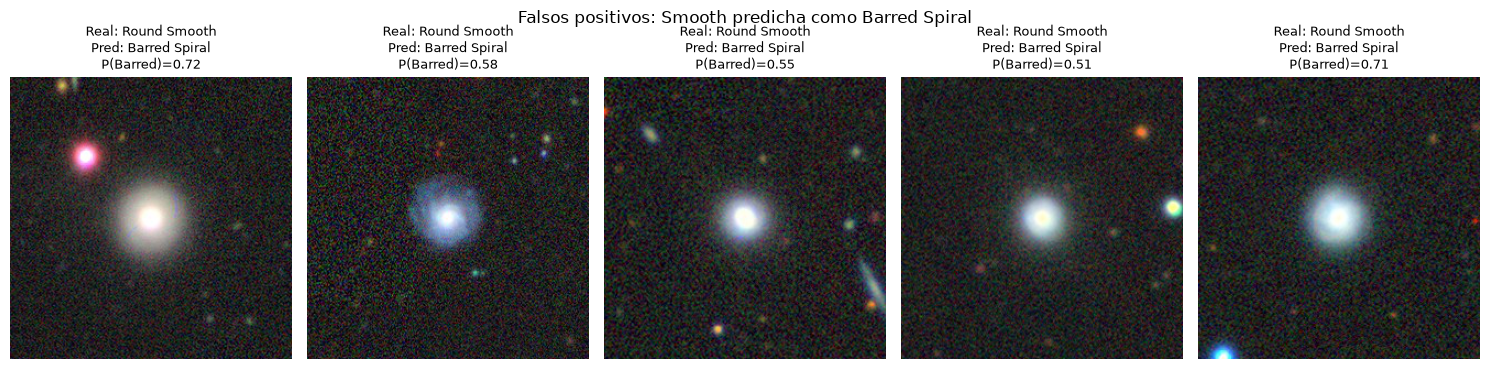

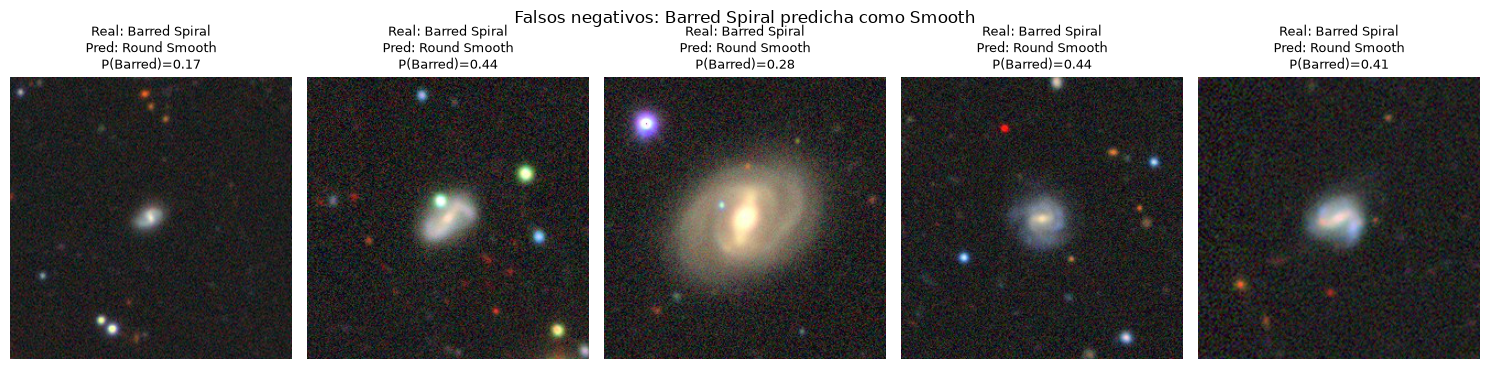

In [15]:
#Ahora para la revisión de galaxias mal clasificadas
misclassified = np.where(y_pred != y_test)[0] #Aquí vemos cuales predicciones no son los resultados verdaderos
missclassified_percent = 100*len(misclassified)/len(y_test)
print(f"Total de todas las mal clasificadas: {len(misclassified)} de {len(y_test)} ({missclassified_percent:.2f}%)")

#Necesitamos ver los falsos negativos y positivos, de forma que los separamos para poder graficarlos
false_positives = misclassified[(y_test[misclassified] == 0) & (y_pred[misclassified] == 1)]
false_negatives = misclassified[(y_test[misclassified] == 1) & (y_pred[misclassified] == 0)]

print(f"Falsos positivos (Round Smooth predicha como Barred Spiral): {len(false_positives)}")
print(f"Falsos negativos (Barred Spiral predicha como Round Smooth): {len(false_negatives)}")

#Para poder elegir una muestra al azar de estas imágenes mal clasificadas creamos un generador aleatorio
rng = np.random.default_rng(42)

def plot_misclassified(idxs, title, n=5):
    sample_idxs = rng.choice(idxs, size=n, replace=False)
    plt.figure(figsize=(15, 4))
    for j, idx in enumerate(sample_idxs):
        plt.subplot(1, n, j + 1)
        plt.imshow(X_test[idx])
        true_label = class_names[y_test[idx]]
        pred_label = class_names[y_pred[idx]]
        prob = y_pred_prob[idx][0]
        plt.title(f"Real: {true_label}\nPred: {pred_label}\nP(Barred)={prob:.2f}", fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_misclassified(false_positives, "Falsos positivos: Smooth predicha como Barred Spiral")
plot_misclassified(false_negatives, "Falsos negativos: Barred Spiral predicha como Smooth")

### Errores del modelo
Viendo las imágenes de las galaxias mal clasificadas, notamos que los errores de clasificación no son azarosos.

En la sección de falsos positivos, se confunden mucho los *Round Smooth* con los *Barred Spiral*. La mayoría de las imágenes muestran galaxias grandes y muy brillantes. Es posible que el modelo asocie el tamaó del halo y el brillo con la clase *Barred Spiral* en algunos casos debido a posibles malinterpretaciones de asimetrías poco definidas.

En la sección de falsos negativos, el caso es contrario. Aquí notamos que el brillo en las estructuras de la galaxia (brazos espirales) es muy bajo en comparación del núcleo. En la mayoría de imagenes podemos distinguir esta estructura espiral, pero es muy tenue en comparación del centro, lo que probablemente dificula que el modeo logre distinguir ambas clases.

Dado que el número de falsos negativos es alto (180, un 44% de todas las Barred Spiral en el set de test), es poco probable que todos sean casos genuinamente ambiguos. Es posible que el modelo tenga un sesgo aprendido a predecir *Round Smooth* por defecto cuando las característica de las espirales no es tan notoria.

## 7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

#### Conclusiones y comentarios finales

Con la evidencia vista tanto en las métricas como en los casos mal clasificados, podemos interpretar varias cosas.
- Los errores no siguen realmente un patrón tan identificable. Esto implica que es muy probable que haya aprendido señales morfológicas, por lo que solo predice *Barred Spiral* cuando la señal es muy fuerte. Sino, por defecto intentará predecir *Round Smooth*.

- Este análisis también nos permitió notar que los errores muestran el límite del modelo. Para este caso, si las imagenes muestran mucho ruido, están contaminadas o sus inclinaciones no son las mejores, entonces el modelo buscará basarse en pistas más superficiales, como lo sería el brillo o la forma general de toda la imagen. Básicamente, busca fuertes indicios de que la galaxia tiene estructuras asimétricas de su núcleo para poder clasificarla como *Barred Spiral*.

Esto sugiere que esta pequeña red convolucional aprendió un patrón morfológico, que no es totalmente incorrecto, pero le quita sensibilidad y además le complica generalizar casos donde esa estructura buscada está presente pero no es tan destacable.